<a href="https://colab.research.google.com/github/Anjanipriya4/DSA0404-FDS/blob/main/Activities/UNIT-02/Libraries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
1.Implement and demonstrate the FIND-S algorithm for finding the most specific hypothesis based on a given set of training data samples.

In [ ]:
training_data = [
    ["Sunny", "Warm", "Normal", "Strong", "Warm", "Same", "Yes"],
    ["Sunny", "Warm", "High", "Strong", "Warm", "Same", "Yes"],
    ["Rainy", "Cold", "High", "Strong", "Warm", "Change", "No"],
    ["Sunny", "Warm", "High", "Strong", "Cool", "Change", "Yes"]
]
def find_s_algorithm(data):
    hypothesis = None
    for example in data:
        attributes = example[:-1]
        target = example[-1]
        if target == "Yes":
            if hypothesis is None:
                hypothesis = attributes.copy()
            else:
                for i in range(len(hypothesis)):
                    if hypothesis[i] != attributes[i]:
                        hypothesis[i] = "?"
    return hypothesis
if __name__ == "__main__":
    result = find_s_algorithm(training_data)
    print("Final Hypothesis:", result)


Final Hypothesis: ['Sunny', 'Warm', '?', 'Strong', '?', '?']


In [ ]:
2.For a given set of training data examples stored in a .CSV file, implement and demonstrate the Candidate-Elimination algorithm in python to output a description of the set of all hypotheses consistent with the training examples

In [ ]:
import csv
dummy_training_data = [
    ["Sunny", "Warm", "Normal", "Strong", "Warm", "Same", "Yes"],
    ["Sunny", "Warm", "High", "Strong", "Warm", "Same", "Yes"],
    ["Rainy", "Cold", "High", "Strong", "Warm", "Change", "No"],
    ["Sunny", "Warm", "High", "Strong", "Cool", "Change", "Yes"]
]
with open("training_data.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Sky", "AirTemp", "Humidity", "Wind", "Water", "Forecast", "EnjoySport"])
    writer.writerows(dummy_training_data)
def candidate_elimination(training_data):
    attributes = len(training_data[0]) - 1
    S = ['0'] * attributes
    G = [['?'] * attributes]
    for example in training_data:
        x = example[:-1]
        label = example[-1]
        if label == "Yes":
            for i in range(attributes):
                if S[i] == '0':
                    S[i] = x[i]
                elif S[i] != x[i]:
                    S[i] = '?'
            G = [g for g in G if all(g[i] == '?' or g[i] == x[i] for i in range(attributes))]
        else:
            new_G = []
            for g in G:
                if all(g[i] == '?' or g[i] == x[i] for i in range(attributes)):
                    for i in range(attributes):
                        if g[i] == '?':
                            if S[i] != '?' and S[i] != '0':
                                new_hypothesis = g.copy()
                                new_hypothesis[i] = S[i]
                                if new_hypothesis not in new_G and all(nh[j] == '?' or nh[j] == x[j] for j, nh in enumerate([new_hypothesis])): # Check consistency of new hypothesis with current negative example
                                     new_G.append(new_hypothesis)
                else:
                    new_G.append(g)
            G = [list(h) for h in set(tuple(h) for h in new_G)]
            G = [g for g in G if all(s_val == '?' or s_val == g_val for s_val, g_val in zip(S, g))]
    return S, G
if __name__ == "__main__":
    training_examples = []
    with open("training_data.csv", "r") as file:
        reader = csv.reader(file)
        next(reader)
        for row in reader:
            training_examples.append(row)
    S_final, G_final = candidate_elimination(training_examples)
    print("Final Specific Hypothesis (S):", S_final)
    print("Final General Hypotheses (G):")
    for g in G_final:
        print(g)


Final Specific Hypothesis (S): ['Sunny', 'Warm', '?', 'Strong', '?', '?']
Final General Hypotheses (G):


In [ ]:
3.Demonstrate the working of the decision tree based ID3 algorithm. Use an appropriate data set for building the decision tree and apply this knowledge to classify a new sample.

In [ ]:
import pandas as pd
import math
from collections import Counter
import csv
dummy_play_tennis_data = [
    ["Sunny", "Hot", "High", "Weak", "No"],
    ["Sunny", "Hot", "High", "Strong", "No"],
    ["Overcast", "Hot", "High", "Weak", "Yes"],
    ["Rain", "Mild", "High", "Weak", "Yes"],
    ["Rain", "Cool", "Normal", "Weak", "Yes"],
    ["Rain", "Cool", "Normal", "Strong", "No"],
    ["Overcast", "Cool", "Normal", "Strong", "Yes"],
    ["Sunny", "Mild", "High", "Weak", "No"],
    ["Sunny", "Cool", "Normal", "Weak", "Yes"],
    ["Rain", "Mild", "Normal", "Weak", "Yes"],
    ["Sunny", "Mild", "Normal", "Strong", "Yes"],
    ["Overcast", "Mild", "High", "Strong", "Yes"],
    ["Overcast", "Hot", "Normal", "Weak", "Yes"],
    ["Rain", "Mild", "High", "Strong", "No"]
]

with open("play_tennis.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Outlook", "Temperature", "Humidity", "Wind", "PlayTennis"])
    writer.writerows(dummy_play_tennis_data)
def entropy(target_col):
    counts = Counter(target_col)
    total = len(target_col)
    ent = 0
    for count in counts.values():
        p = count / total
        ent -= p * math.log2(p)
    return ent
def information_gain(df, attribute, target):
    total_entropy = entropy(df[target])
    values = df[attribute].unique()
    weighted_entropy = 0
    for val in values:
        subset = df[df[attribute] == val]
        weighted_entropy += (len(subset)/len(df)) * entropy(subset[target])
    return total_entropy - weighted_entropy
def id3(df, target, attributes):
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]
    if not attributes:
        return df[target].mode()[0]
    gains = [information_gain(df, attr, target) for attr in attributes]
    best_attr = attributes[gains.index(max(gains))]
    tree = {best_attr: {}}
    for val in df[best_attr].unique():
        subset = df[df[best_attr] == val]
        if subset.empty:
            tree[best_attr][val] = df[target].mode()[0]
        else:
            remaining_attrs = [attr for attr in attributes if attr != best_attr]
            tree[best_attr][val] = id3(subset, target, remaining_attrs)
    return tree
def classify(sample, tree):
    if not isinstance(tree, dict):
        return tree
    attribute = next(iter(tree))
    value = sample[attribute]
    subtree = tree[attribute].get(value)
    if subtree is None:
        return "Unknown"
    return classify(sample, subtree)

if __name__ == "__main__":
    df = pd.read_csv("play_tennis.csv")
    attributes = list(df.columns[:-1])
    decision_tree = id3(df, "PlayTennis", attributes)
    print("Decision Tree:", decision_tree)
    new_sample = {
        "Outlook": "Sunny",
        "Temperature": "Cool",
        "Humidity": "High",
        "Wind": "Strong"
    }
    prediction = classify(new_sample, decision_tree)
    print("Prediction for new sample:", prediction)


Decision Tree: {'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}
Prediction for new sample: No


In [ ]:
4.Build an Artificial Neural Network by implementing the Backpropagation algorithm and test the same using appropriate data sets.

In [ ]:
# Calculate Mean Squared Error
mse = np.mean(np.square(y - predicted_output))
print(f"\nMean Squared Error (MSE): {mse:.4f}")

# Calculate Accuracy for binary classification
# Convert probabilities to binary predictions (0 or 1)
predicted_labels = (predicted_output > 0.5).astype(int)
accuracy = np.mean(predicted_labels == y)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Function to make a single prediction after training
def predict(input_data):
    hidden_layer_input = np.dot(input_data, W1) + b1
    hidden_layer_output = sigmoid(hidden_layer_input)
    output_layer_input = np.dot(hidden_layer_output, W2) + b2
    predicted_output_single = sigmoid(output_layer_input)
    return (predicted_output_single > 0.5).astype(int)

print("\n--- Testing with New Inputs ---")
# Test with a new input (e.g., [0, 0])
new_input_00 = np.array([[0, 0]])
prediction_00 = predict(new_input_00)
print(f"Prediction for input {new_input_00[0]}: {prediction_00[0][0]}")

# Test with a new input (e.g., [0, 1])
new_input_01 = np.array([[0, 1]])
prediction_01 = predict(new_input_01)
print(f"Prediction for input {new_input_01[0]}: {prediction_01[0][0]}")

# Test with a new input (e.g., [1, 0])
new_input_10 = np.array([[1, 0]])
prediction_10 = predict(new_input_10)
print(f"Prediction for input {new_input_10[0]}: {prediction_10[0][0]}")

# Test with a new input (e.g., [1, 1])
new_input_11 = np.array([[1, 1]])
prediction_11 = predict(new_input_11)
print(f"Prediction for input {new_input_11[0]}: {prediction_11[0][0]}")


Mean Squared Error (MSE): 0.0003
Accuracy: 100.00%

--- Testing with New Inputs ---
Prediction for input [0 0]: 0
Prediction for input [0 1]: 1
Prediction for input [1 0]: 1
Prediction for input [1 1]: 0


In [ ]:
5.Write a program for Implementation of K-Nearest Neighbours (K-NN) in Python.

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix, classification_report

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Prepare features (X) and target (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Standardize features (important for distance-based algorithms like KNN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# K-Nearest Neighbors (KNN) Classifier Implementation
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        # Calculate distances from the new data point 'x' to all training data points
        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]

        # Get the indices of the k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # Get the labels of the k nearest neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Return the most common label among the k nearest neighbors
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

# Initialize and train the KNN model
knn = KNN(k=5) # Using k=5 as an example
knn.fit(X_train, y_train)

# Make predictions on the test set
predictions = knn.predict(X_test)

# Evaluate the model
accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Display Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=iris.target_names))

# Predict for a new sample
# Let's take the first sample from the Iris dataset and pretend it's a new, unseen sample
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])
# Scale the new sample using the same scaler fitted on the training data
new_sample_scaled = scaler.transform(new_sample)

predicted_class_index = knn.predict(new_sample_scaled)[0]
predicted_class_name = iris.target_names[predicted_class_index]
print(f"\nPrediction for a new sample {new_sample[0]} (scaled): {new_sample_scaled[0]}")
print(f"Predicted Class: {predicted_class_name}")


Accuracy: 100.00%

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Prediction for a new sample [5.1 3.5 1.4 0.2] (scaled): [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
Predicted Class: setosa


In [ ]:
6.Write a program to implement Naïve Bayes algorithm in python and to display the results using confusion matrix and accuracy.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Prepare features (X) and target (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Initialize and train the Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Display Classification Report for more detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Predict for a new sample
# Let's take the first sample from the Iris dataset and pretend it's a new, unseen sample
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])
predicted_class_index = model.predict(new_sample)[0]
predicted_class_name = iris.target_names[predicted_class_index]
print(f"\nPrediction for a new sample {new_sample[0]}:")
print(f"Predicted Class: {predicted_class_name}")


Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]
Accuracy: 97.78%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


Prediction for a new sample [5.1 3.5 1.4 0.2]:
Predicted Class: setosa


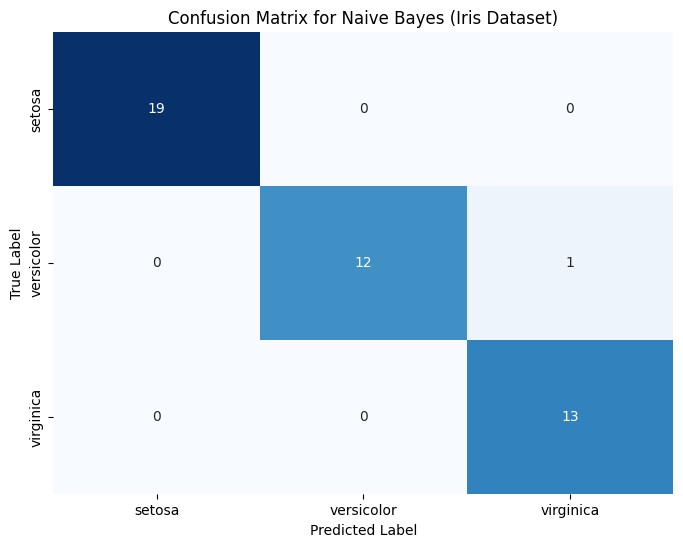

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Naive Bayes (Iris Dataset)')
plt.show()

In [ ]:
7.Write a program to implement Logistic Regression (LR) algorithm in python.

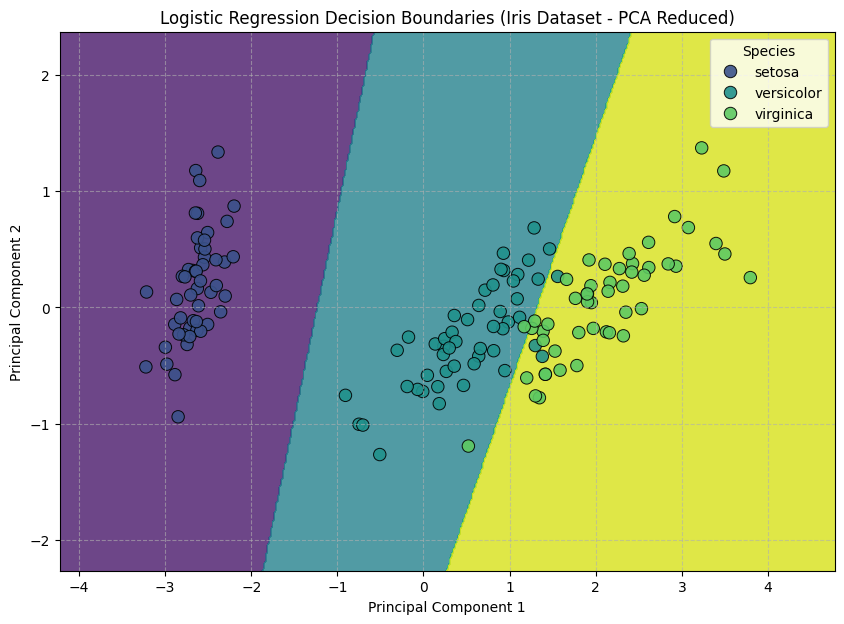

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression # Added this import
from sklearn.model_selection import train_test_split
import numpy as np # Added this import as np is used later

# Perform PCA to reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X) # Use the scaled X from the previous cell

# Split the PCA-transformed data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

# Re-train Logistic Regression on the 2-component PCA data
model_pca = LogisticRegression(max_iter=200)
model_pca.fit(X_train_pca, y_train_pca)

# Create a meshgrid for plotting the decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the meshgrid
Z = model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundaries
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')

# Plot the actual data points
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=iris.target_names[y],
    palette='viridis', s=80, alpha=0.9, edgecolor='k'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Logistic Regression Decision Boundaries (Iris Dataset - PCA Reduced)')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
8.Write a program to implement Linear Regression (LR) algorithm in python.

Slope: 9339.081723815198
Intercept: 25918.438334893202
MSE: 37784662.47
R2 Score: 0.9414


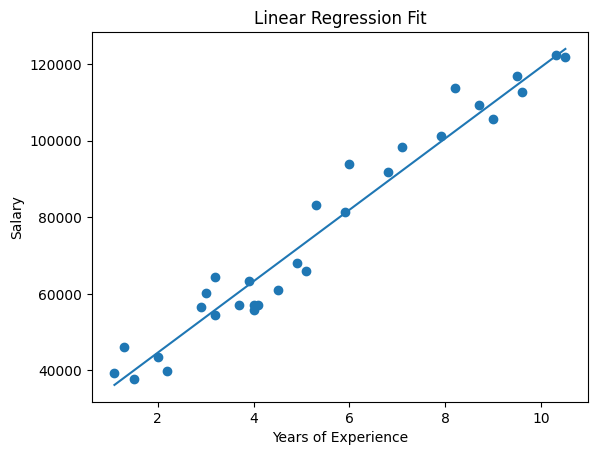

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import csv
dummy_regression_data = [
    [1.1, 39343],
    [1.3, 46205],
    [1.5, 37731],
    [2.0, 43525],
    [2.2, 39891],
    [2.9, 56642],
    [3.0, 60150],
    [3.2, 54445],
    [3.2, 64445],
    [3.7, 57189],
    [3.9, 63218],
    [4.0, 55794],
    [4.0, 56957],
    [4.1, 57081],
    [4.5, 61111],
    [4.9, 67938],
    [5.1, 66029],
    [5.3, 83088],
    [5.9, 81363],
    [6.0, 93940],
    [6.8, 91738],
    [7.1, 98273],
    [7.9, 101302],
    [8.2, 113812],
    [8.7, 109431],
    [9.0, 105582],
    [9.5, 116969],
    [9.6, 112635],
    [10.3, 122391],
    [10.5, 121872]
]
with open("linear_regression_dataset.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["YearsExperience", "Salary"])
    writer.writerows(dummy_regression_data)
df = pd.read_csv("linear_regression_dataset.csv")
X = df[["YearsExperience"]].values
y = df["Salary"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("MSE:", round(mse, 2))
print("R2 Score:", round(r2, 4))
plt.figure()
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Fit")
plt.show()


In [ ]:
9.Compare Linear and Polynomial Regression using Python.

Linear Regression R2 Score: 0.8825
Polynomial Regression R2 Score: 0.916


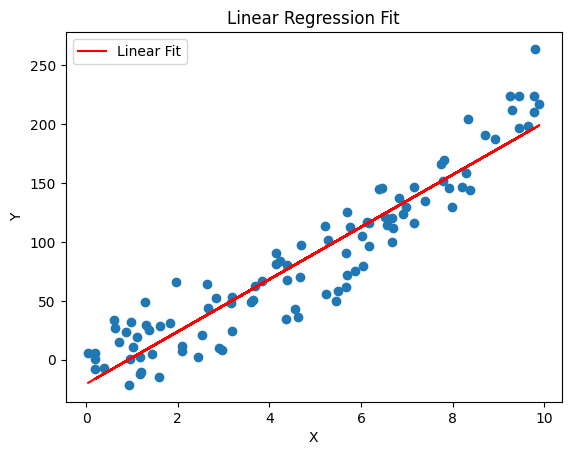

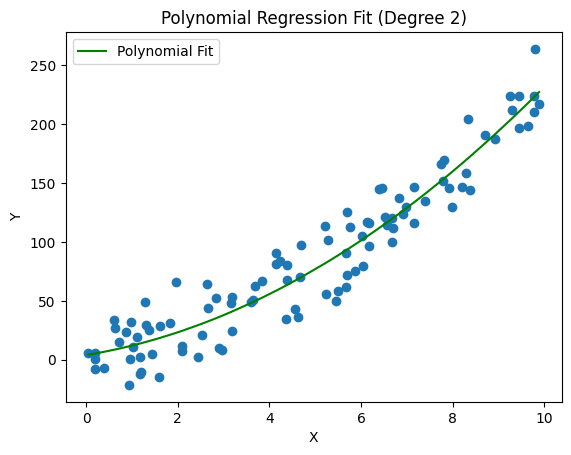

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import csv
np.random.seed(0)
X_data = np.random.rand(100, 1) * 10
y_data = 2 * X_data**2 + 3 * X_data + 5 + np.random.randn(100, 1) * 20
dummy_regression_data = []
for i in range(len(X_data)):
    dummy_regression_data.append([X_data[i][0], y_data[i][0]])
with open("regression_comparison_dataset.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["X", "Y"])
    writer.writerows(dummy_regression_data)
df = pd.read_csv("regression_comparison_dataset.csv")
X = df[["X"]].values
y = df["Y"].values.reshape(-1, 1)
lin_model = LinearRegression()
lin_model.fit(X, y)
y_lin_pred = lin_model.predict(X)
r2_linear = r2_score(y, y_lin_pred)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_poly)
r2_poly = r2_score(y, y_poly_pred)
print("Linear Regression R2 Score:", round(r2_linear, 4))
print("Polynomial Regression R2 Score:", round(r2_poly, 4))
plt.figure()
plt.scatter(X, y)
plt.plot(X, y_lin_pred, color='red', label='Linear Fit')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()
plt.figure()
plt.scatter(X, y)
sort_idx = X.flatten().argsort()
X_sorted = X.flatten()[sort_idx].reshape(-1, 1)
y_poly_pred_sorted = y_poly_pred[sort_idx]
plt.plot(X_sorted, y_poly_pred_sorted, color='green', label='Polynomial Fit')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression Fit (Degree 2)")
plt.legend()
plt.show()


In [ ]:
10.Write a Python Program to Implement Expectation & Maximization Algorithm.

Means: [1.87216611 6.95921498]
Variances: [0.80401448 2.27177687]
Weights: [0.49034516 0.50965484]


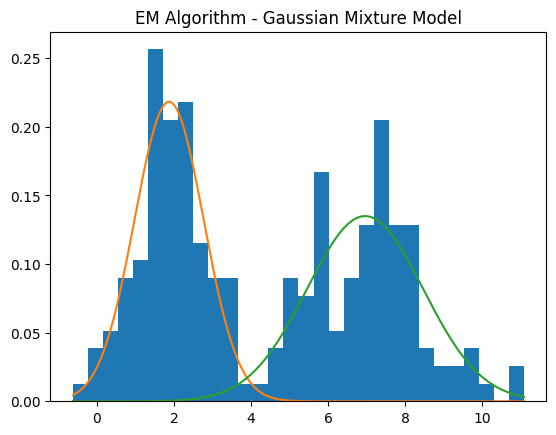

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import csv
np.random.seed(42)
data_g1 = np.random.normal(loc=2, scale=1, size=100)
data_g2 = np.random.normal(loc=7, scale=1.5, size=100)
dummy_em_data = np.concatenate((data_g1, data_g2))
np.random.shuffle(dummy_em_data)
with open("em_dataset.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Data"])
    for val in dummy_em_data:
        writer.writerow([val])
df = pd.read_csv("em_dataset.csv")
data = df["Data"].values
k = 2
n = len(data)
means = np.random.choice(data, k)
variances = np.random.random(k) * 10
weights = np.ones(k) / k
def em_algorithm(data, means, variances, weights, iterations=50):
    n = len(data)
    k = len(means)
    for iteration in range(iterations):
        responsibilities = np.zeros((n, k))
        for i in range(k):
            responsibilities[:, i] = weights[i] * norm.pdf(data, means[i], np.sqrt(variances[i]))
        responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
        Nk = responsibilities.sum(axis=0)
        for i in range(k):
            means[i] = np.sum(responsibilities[:, i] * data) / Nk[i]
            variances[i] = np.sum(responsibilities[:, i] * (data - means[i])**2) / Nk[i]
            weights[i] = Nk[i] / n
    return means, variances, weights
means, variances, weights = em_algorithm(data, means, variances, weights)
print("Means:", means)
print("Variances:", variances)
print("Weights:", weights)
x = np.linspace(min(data), max(data), 500)
plt.figure()
plt.hist(data, bins=30, density=True)
for i in range(k):
    plt.plot(x, weights[i] * norm.pdf(x, means[i], np.sqrt(variances[i])))
plt.title("EM Algorithm - Gaussian Mixture Model")
plt.show()

In [ ]:
11.Write a program for the task of Credit Score Classification.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
data = {
    'Age': [25, 35, 45, 20, 50, 30, 40, 28, 55, 32],
    'Income': [30000, 50000, 70000, 20000, 90000, 45000, 65000, 35000, 100000, 48000],
    'LoanAmount': [5000, 10000, 15000, 3000, 20000, 8000, 12000, 6000, 25000, 9000],
    'CreditScore': ['Poor', 'Standard', 'Good', 'Poor', 'Good',
                    'Standard', 'Good', 'Poor', 'Good', 'Standard']
}
df = pd.DataFrame(data)
le = LabelEncoder()
df['CreditScore'] = le.fit_transform(df['CreditScore'])
X = df[['Age', 'Income', 'LoanAmount']]
y = df['CreditScore']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
new_customer = [[30, 55000, 10000]]
prediction = model.predict(new_customer)

print("\nPredicted Credit Score:",
      le.inverse_transform(prediction)[0])

Accuracy: 0.6666666666666666

Confusion Matrix:
[[1 0 0]
 [0 0 0]
 [0 1 1]]

Predicted Credit Score: Poor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
12.Implement Iris Flower Classification using KNN.

In [ ]:
# Iris Flower Classification using KNN

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Iris Dataset
iris = load_iris()

X = iris.data      # Features
y = iris.target    # Target labels

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train, y_train)

# Predict on test data
y_pred = knn.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict a new flower
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = knn.predict(sample)

print("\nPredicted Class:", iris.target_names[prediction][0])

Accuracy: 1.0

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Predicted Class: setosa


In [ ]:
13.Implement the Car Price Prediction Model using Python.

In [ ]:
# Car Price Prediction using Linear Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Sample Car Dataset
data = {
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
    'Mileage': [50000, 45000, 40000, 35000, 30000, 25000, 20000, 15000],
    'Price': [500000, 550000, 600000, 650000, 700000, 750000, 800000, 850000]
}

df = pd.DataFrame(data)

# Features and Target
X = df[['Year', 'Mileage']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Predict price of a new car
new_car = [[2023, 10000]]
predicted_price = model.predict(new_car)

print("\nPredicted Car Price: ₹", round(predicted_price[0], 2))

Mean Squared Error: 3.3881317890172014e-20
R2 Score: 1.0

Predicted Car Price: ₹ 900000.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
14.Implement House price Prediction using appropriate machine learning algorithm.

In [ ]:
# House Price Prediction using Linear Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Sample House Dataset
data = {
    'Area': [1000, 1200, 1500, 1800, 2000, 2200, 2500, 3000],
    'Bedrooms': [2, 2, 3, 3, 4, 4, 4, 5],
    'Age': [20, 18, 15, 12, 10, 8, 5, 2],
    'Price': [2000000, 2500000, 3200000, 4000000,
              4500000, 5000000, 6000000, 7500000]
}

# Create DataFrame
df = pd.DataFrame(data)

# Features and Target
X = df[['Area', 'Bedrooms', 'Age']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Model Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Predict price for a new house
new_house = [[2400, 4, 6]]   # Area, Bedrooms, Age
predicted_price = model.predict(new_house)

print("\nPredicted House Price: ₹", round(predicted_price[0], 2))

Mean Squared Error: 3270338404.439554
R2 Score: 0.9979069834211587

Predicted House Price: ₹ 5656485.36


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
15.Implement Iris Flower Classification using Naive Bayes classifier.

In [ ]:
# Iris Flower Classification using Naive Bayes

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Iris Dataset
iris = load_iris()

X = iris.data      # Features
y = iris.target    # Target labels

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Naive Bayes Classifier
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict a new flower
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)

print("\nPredicted Class:", iris.target_names[prediction][0])

Accuracy: 0.9777777777777777

Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

Predicted Class: setosa


In [ ]:
16.Compare different types Classification Algorithms and evaluate their performance.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import pandas as pd

# Load Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Classification Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

# Train and Evaluate Models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, round(acc * 100, 2)])

# Display Results
result_df = pd.DataFrame(results,
                         columns=["Algorithm", "Accuracy (%)"])

print(result_df)

             Algorithm  Accuracy (%)
0  Logistic Regression        100.00
1                  KNN        100.00
2          Naive Bayes         97.78
3        Decision Tree        100.00
4                  SVM        100.00


In [ ]:
17.Implement Mobile Price Prediction using appropriate machine learning algorithm.

In [ ]:
# Mobile Price Prediction using Random Forest

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Sample Mobile Dataset
data = {
    'RAM': [2, 3, 4, 6, 8, 12, 4, 6, 8, 12],
    'Battery': [2000, 2500, 3000, 3500, 4000, 5000, 2800, 3200, 4500, 5500],
    'Memory': [16, 32, 64, 64, 128, 256, 32, 64, 128, 256],
    'Weight': [150, 155, 160, 170, 180, 190, 158, 168, 178, 195],
    'PriceRange': [0, 0, 1, 1, 2, 3, 0, 1, 2, 3]
}

df = pd.DataFrame(data)

# Features and Target
X = df[['RAM', 'Battery', 'Memory', 'Weight']]
y = df['PriceRange']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Predict New Mobile
new_mobile = [[8, 4500, 128, 175]]
prediction = model.predict(new_mobile)

print("\nPredicted Price Range:", prediction[0])

Accuracy: 1.0

Confusion Matrix:
[[1 0 0]
 [0 1 0]
 [0 0 1]]

Predicted Price Range: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
18.Implement Perceptron based IRIS classification.

In [ ]:
# Perceptron based Iris Classification

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix

# Load Iris Dataset
iris = load_iris()

X = iris.data      # Features
y = iris.target    # Target labels

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create Perceptron Model
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)
print("\nPredicted Class:", iris.target_names[prediction][0])

Accuracy: 0.4666666666666667

Confusion Matrix:
[[19  0  0]
 [12  1  0]
 [11  1  1]]

Predicted Class: setosa


In [ ]:
19.Implementation of Naive Bayes classification for Bank Loan prediction.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
data = {
    'Age': [25, 35, 45, 20, 50, 30, 40, 28, 55, 32],
    'Income': [30000, 50000, 70000, 20000, 90000, 45000, 65000, 35000, 100000, 48000],
    'CreditScore': [600, 700, 750, 580, 800, 680, 720, 620, 850, 690],
    'LoanApproved': [0, 1, 1, 0, 1, 1, 1, 0, 1, 1]
}
df = pd.DataFrame(data)
X = df[['Age', 'Income', 'CreditScore']]
y = df['LoanApproved']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
new_customer = [[40, 60000, 720]]
prediction = model.predict(new_customer)
if prediction[0] == 1:
    print("\nLoan Approved")
else:
    print("\nLoan Not Approved")

Accuracy: 1.0

Confusion Matrix:
[[3]]

Loan Approved


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [ ]:
20.Implement Future Sales Prediction using a suitable machine learning algorithm.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
data = {
    'Month': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Sales': [120, 135, 150, 165, 180, 200, 220, 240, 260, 280]
}
df = pd.DataFrame(data)
X = df[['Month']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
future_month = [[12]]
future_sales = model.predict(future_month)

print("\nPredicted Sales for Month 12:", round(future_sales[0], 2))

Mean Squared Error: 9.777236920332935
R2 Score: 0.9974970273483947

Predicted Sales for Month 12: 310.65


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
